In [1]:
import os
import urllib.request
import zipfile
from functools import partial

import pandas as pd
import xarray as xr
import pynncml

from pynncml.datasets.dataset import LinkDataset
from pynncml.datasets.gauge_data import PointSensor
from pynncml.datasets import PointSet
import numpy as np
import netCDF4 as nc

from pynncml.datasets.xarray_processing import xarray2link, LinkSelection

from scipy.interpolate import interp1d

import sys
from pathlib import Path

In [2]:
import os
from pathlib import Path

# find the OpenMesh-1 root automatically
root = Path.cwd()

while root.name != "OpenMesh_pynncml":
    root = root.parent

os.chdir(root)
print("Working directory set to:", root)


Working directory set to: /Users/drorjac/OpenMesh_pynncml


In [3]:
import sys
from pathlib import Path

# Add the notebooks directory to Python path
# Since Cell 1 changes cwd to project root, we need the relative path from there
notebooks_dir = Path.cwd() / 'src' / 'analysis' / 'pynncml_experiments' / 'notebooks'
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

from load_link_set import *

Import files

In [4]:
# ============================================
# PATH CONFIGURATION
# ============================================
from pathlib import Path

# Choose user
USER = "dror"  # Options: "user" or "dror"

# Base path (relative to project root - Cell 1 sets working directory to project root)
BASE_PATH = Path("dataset")

# All paths built from base path
linkspath = str(BASE_PATH / "links" / "ds_openmesh.nc")
metapath = str(BASE_PATH / "links" / "links_metadata.csv")
# Note: pws_opensense_sample_jan.nc is in dataset root, not in weather stations folder
gaugespath = str(BASE_PATH / "pws_opensense_sample_jan.nc")
gaugemetapath = str(BASE_PATH / "weather stations" / "pws_metadata.csv")

# Load data
with xr.open_dataset(linkspath) as ds:
    pass
links_meta = pd.read_csv(metapath)




1. Gauge data to Point Sensors

In [5]:
# CREATE POINT SENSORS
ps = guage_to_linkset(gaugemetapath, gaugespath)


CONVERTING NETCDF GROUPS TO XARRAY DICT

  ✓ KNYNEWYO1472: 4402 records
  ✓ KNYNEWYO1659: 4606 records
  ✓ KNYNEWYO1288: 3743 records
  ✓ KNYNEWYO1896: 4606 records
  ✓ KNYNEWYO1921: 4605 records
  ✓ KNYNEWYO1931: 4606 records
  ✓ KNYNEWYO1313: 4604 records
  ✓ KNYNEWYO1918: 4604 records
  ✓ KNYNEWYO1298: 4606 records
  ✓ KNYNEWYO1388: 4599 records
  ✓ KNYNEWYO1606: 4606 records
  ✓ KNYNEWYO1943: 290 records
  ✓ KNYNEWYO1348: 4606 records
  ✓ KNYNEWYO1942: 373 records
  ✓ KNYNEWYO1238: 4544 records
  ✓ KNYNEWYO1401: 4587 records
  ✓ KNYNEWYO1824: 4605 records
  ✓ KNYNEWYO343: 4606 records
  ✓ KNYNEWYO1626: 4604 records
  ✓ KNYNEWYO1747: 1171 records
  ✓ KNYNEWYO589: 4605 records
  ✓ KNYNEWYO1591: 4606 records
  ✓ KNYNEWYO638: 3958 records
  ✓ KNYNEWYO1796: 4606 records
  ✓ KNYNEWYO1805: 4534 records
  ✓ KNYNEWYO1622: 4606 records
  ✓ KNYNEWYO1024: 1506 records
  ✓ KNYNEWYO1533: 4580 records
  ✓ KNYNEWYO1651: 1534 records
  ✓ KNYNEWYO1120: 4606 records
  ✓ KNYNEWYO1900: 4605 records
  


Plotting data for 37 gauges from PointSet...



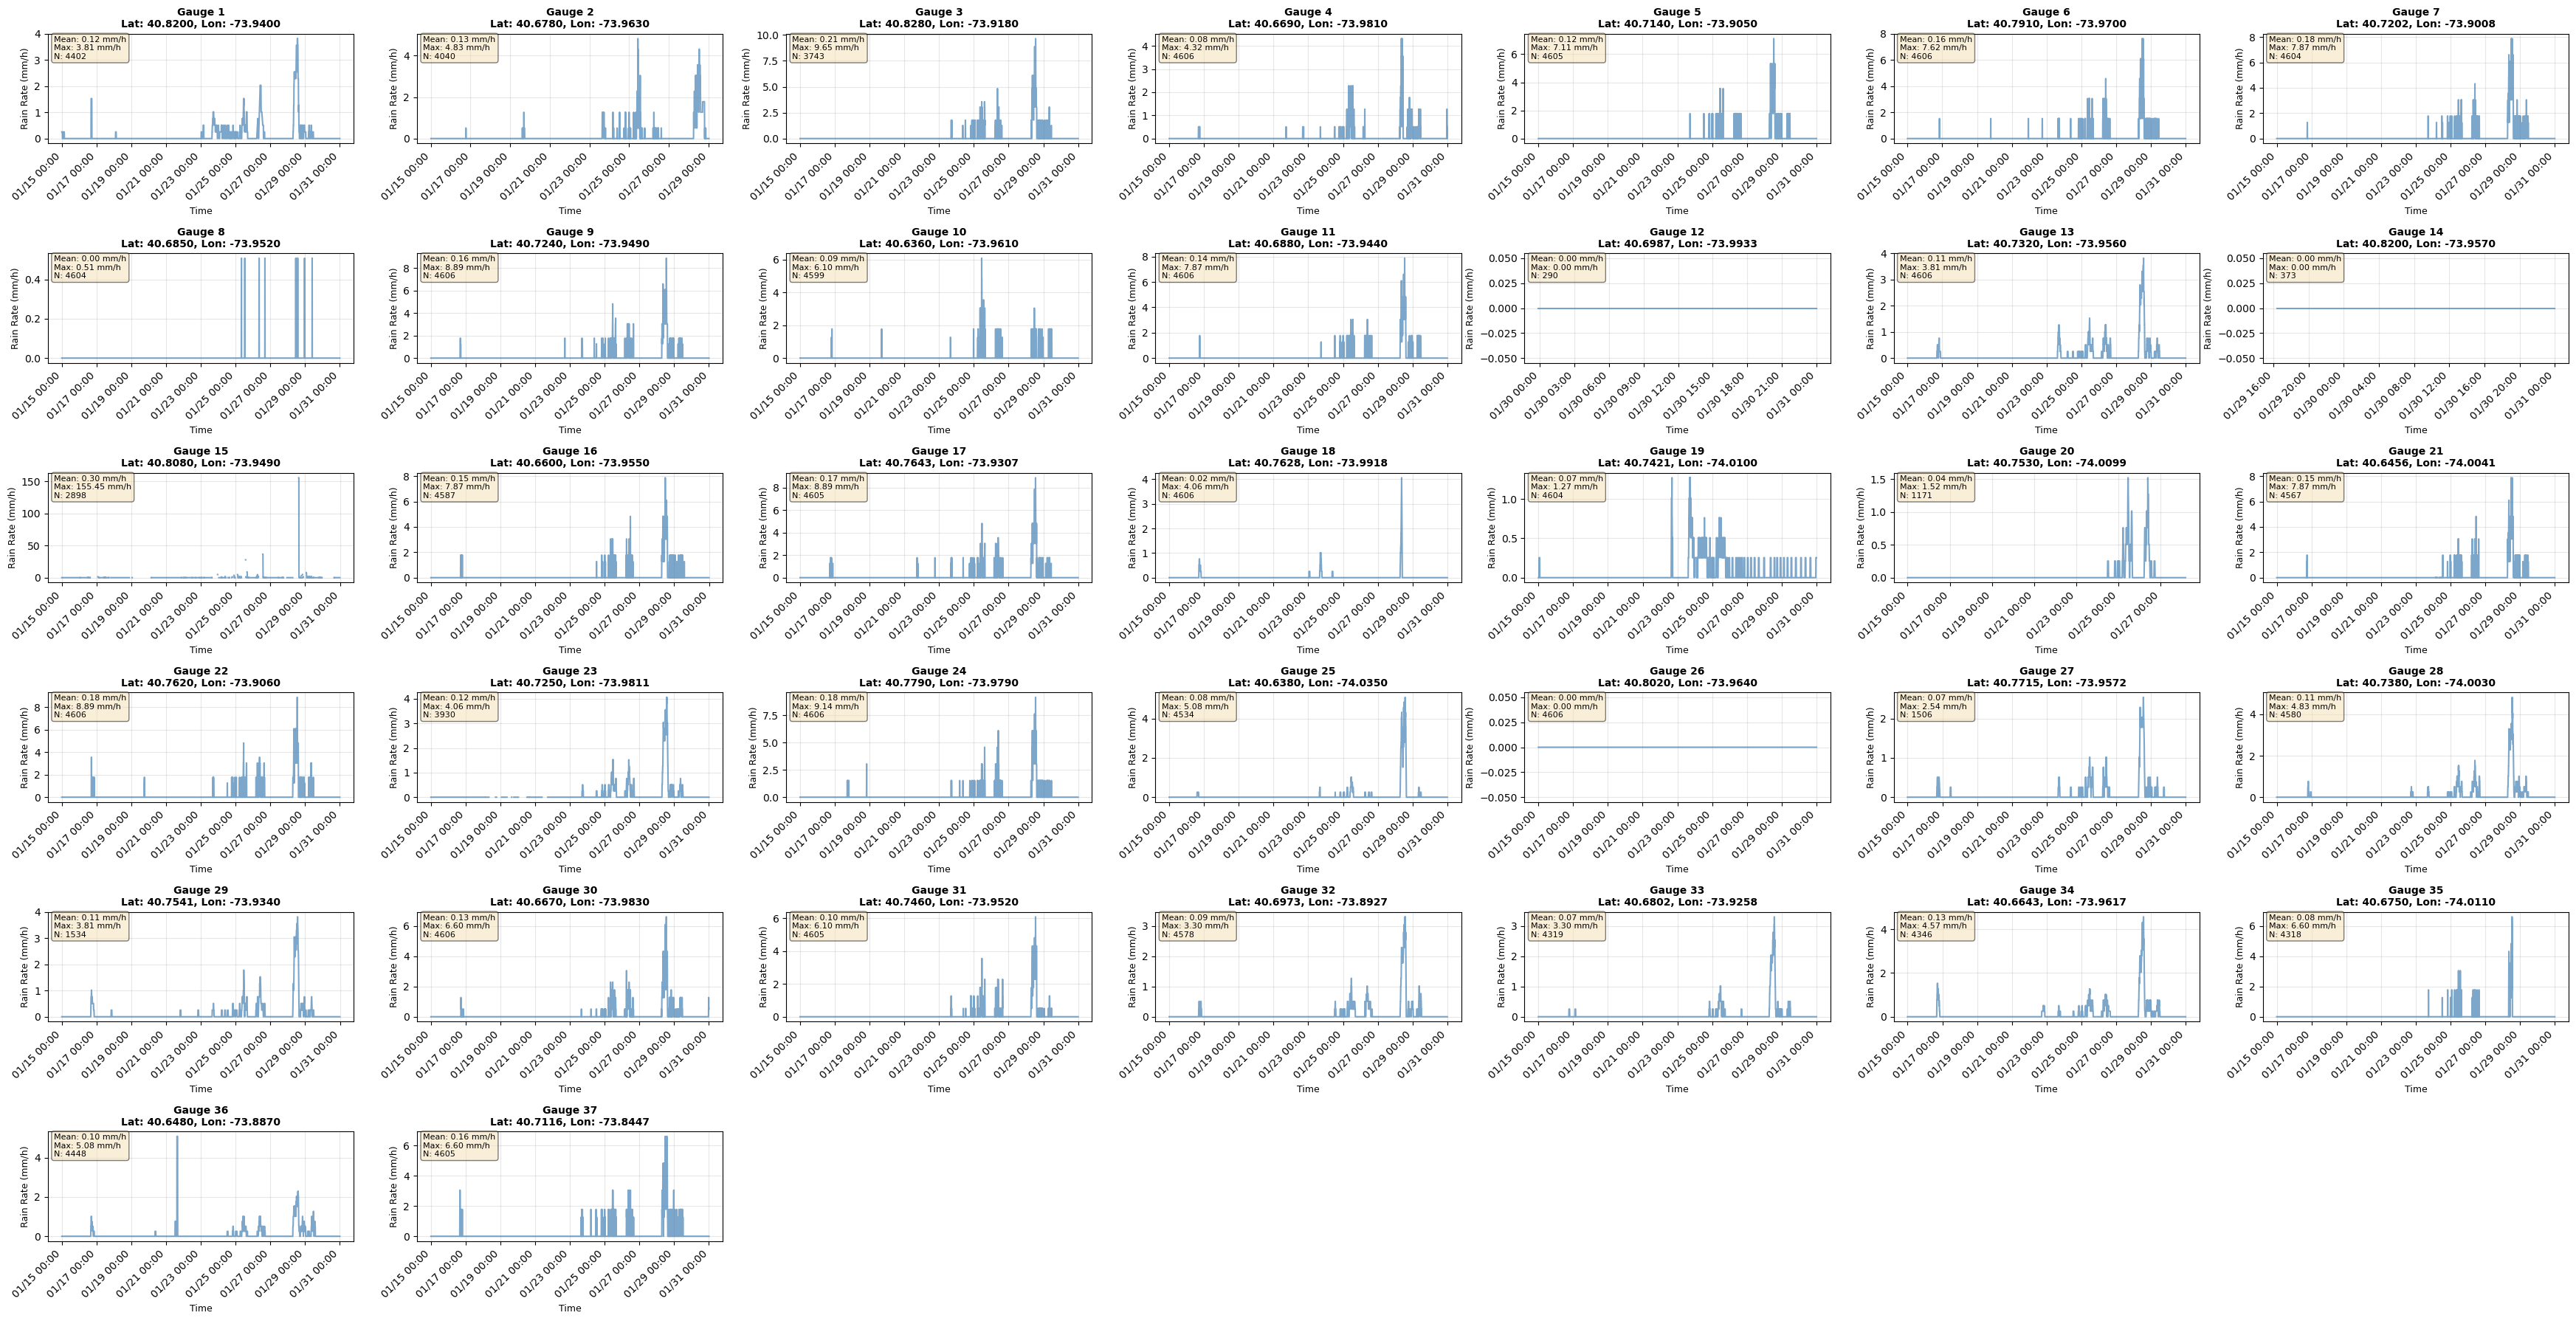

✓ Plotted 37 gauges from PointSet


In [6]:
# ============================================
# PLOT EACH GAUGE IN POINTSET (ps) OVER TIME
# ============================================
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import numpy as np

# Get number of gauges in PointSet
n_gauges = len(ps.point_set)
print(f"\nPlotting data for {n_gauges} gauges from PointSet...\n")

# Determine subplot layout (aim for roughly square grid)
n_cols = int(np.ceil(np.sqrt(n_gauges)))
n_rows = int(np.ceil(n_gauges / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
# Flatten axes array for easier indexing
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes] if not isinstance(axes, list) else axes

# Plot each gauge in the PointSet
for idx, gauge in enumerate(ps.point_set):
    ax = axes[idx]
    
    # Get time and data arrays
    time_array = gauge.time_array
    data_array = gauge.data_array
    
    # Convert time to datetime if it's Unix timestamp
    if np.issubdtype(time_array.dtype, np.number):
        # Assume Unix timestamp (seconds since epoch)
        time_datetime = pd.to_datetime(time_array, unit='s')
    else:
        time_datetime = pd.to_datetime(time_array)
    
    # Plot the data
    ax.plot(time_datetime, data_array, linewidth=1.5, alpha=0.7, color='steelblue')
    ax.set_title(f'Gauge {idx+1}\nLat: {gauge.lat:.4f}, Lon: {gauge.lon:.4f}', 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Time', fontsize=9)
    ax.set_ylabel('Rain Rate (mm/h)', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis dates
    ax.xaxis.set_major_formatter(DateFormatter('%m/%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Add statistics text
    valid_data = data_array[~np.isnan(data_array)]
    if len(valid_data) > 0:
        stats_text = f'Mean: {np.nanmean(data_array):.2f} mm/h\nMax: {np.nanmax(data_array):.2f} mm/h\nN: {len(valid_data)}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax.text(0.5, 0.5, 'No valid data', transform=ax.transAxes,
                fontsize=10, ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

# Hide unused subplots
for idx in range(n_gauges, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print(f"✓ Plotted {n_gauges} gauges from PointSet")


2. From xarray to LinkSet

In [7]:
# Create the LinkSet with validation
link_set = patched_xarray2link_with_gauges(ds, ps, max_distance=5000)

print(f"✅ Created LinkSet with {len(link_set)} sublinks")

Processing sublinks:   0%|          | 0/3 [00:00<?, ?it/s]/Users/drorjac/OpenMesh_pynncml/src/analysis/pynncml_experiments/notebooks/load_link_set.py:267: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
/Users/drorjac/OpenMesh_pynncml/src/analysis/pynncml_experiments/notebooks/load_link_set.py:267: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
/Users/drorjac/OpenMesh_pynncml/src/analysis/pynncml_experiments/notebooks/load_link_set.py:267: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
/Users/drorjac/OpenMesh_pynncml/src/analysis/pynncml_experiments/notebooks/load_link_set.py:267: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
/Users/drorjac/OpenMesh_pynncml/src/analysis/pynncml_experiments/notebooks/load_link_set.py:267: RuntimeWarning: Mean of empty slice
  averaged_data = np.nanmean(stacked_arrays, axis=0)
/Users/drorj


Processing Summary:
  ✅ Valid links created: 103
  ⚠️  Skipped (missing coordinates): 0
  ⚠️  Skipped (no RSL data): 122
  📊 Total processed: 225

✅ Created LinkSet with 103 sublinks


### Rain detection for short periods on high frequency sublinks

Get High frequency sublinks:

In [8]:
highfreq = [
    link
    for link in link_set.link_list
    if link.meta_data.frequency > 68.0
]

highfreqID = []
for i in range(0,len(link_set)):
    if link_set.get_link(i).meta_data.frequency >= 68:
        highfreqID.append(i)

highfreqID

[0, 2, 7, 16, 19, 21, 28, 30, 31, 33, 35, 39, 44, 75, 91, 101]

Rain detection:

Overlap period: 2024-01-15T00:04:00 to 2024-01-30T23:59:00
Link WD data points: 23036
Gauge data points: 23036
Interpolated detection length: 23036


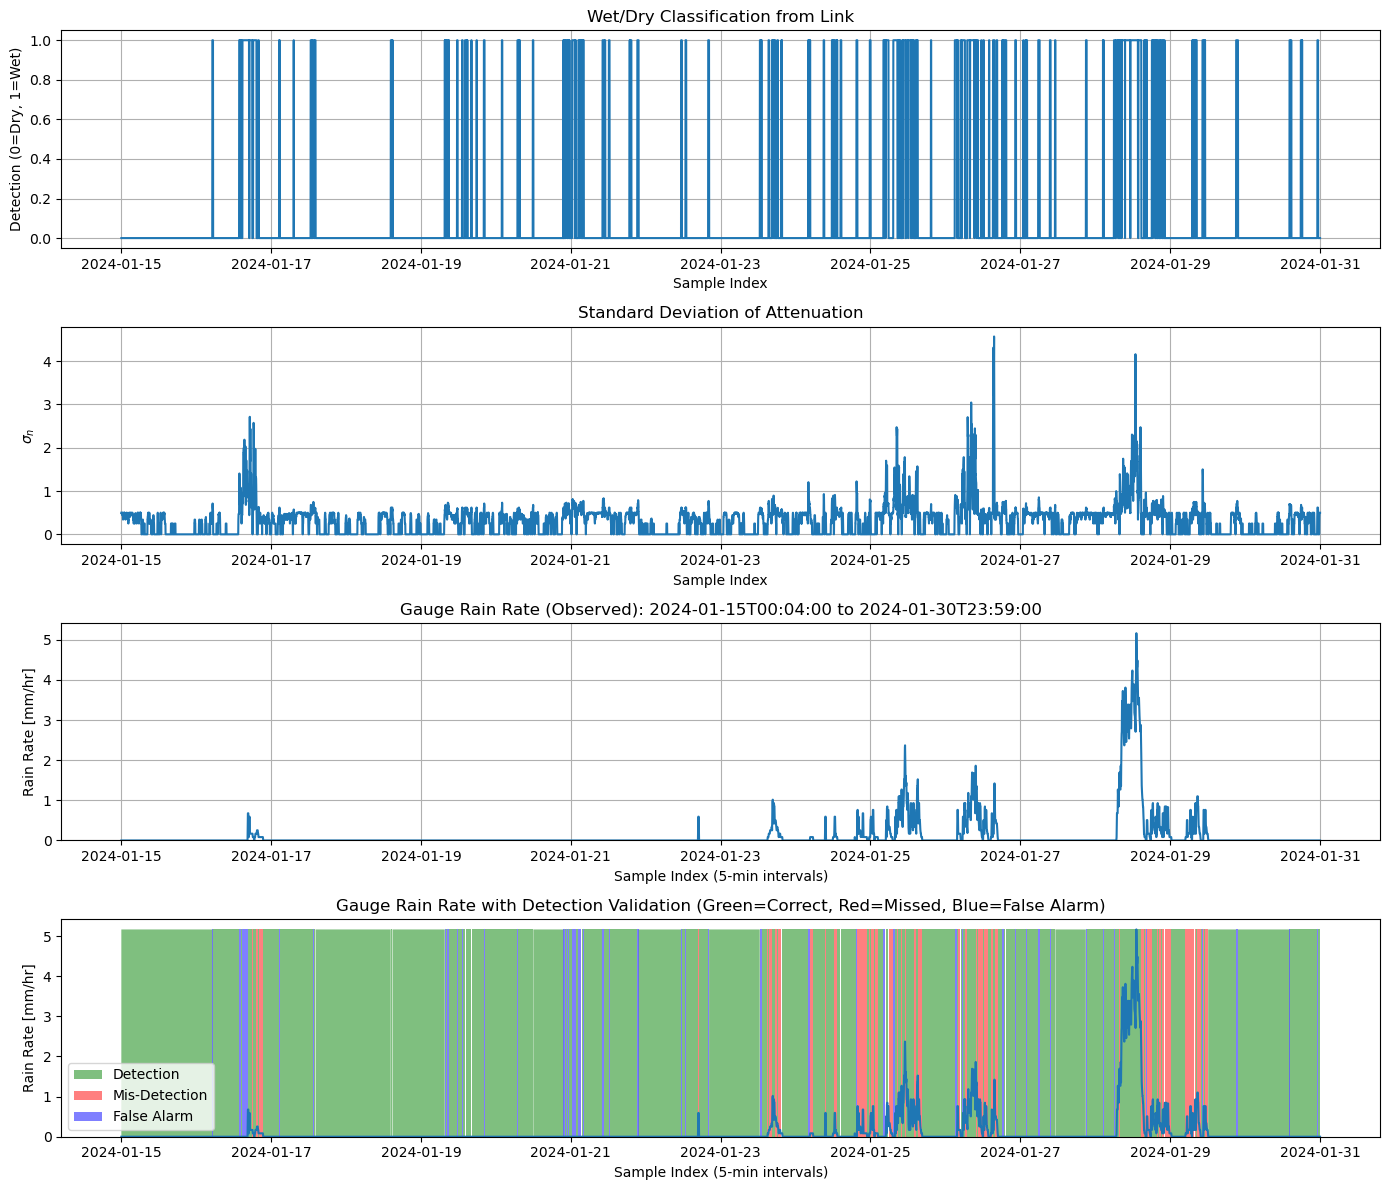


📊 Detection Performance:
  True Positives (correctly detected rain): 1654
  True Negatives (correctly detected dry): 17762
  False Positives (false alarms): 1361
  False Negatives (missed rain): 2259
  Positive detection: 0.42269358548428315
  Negative detection: 0.9288291586048214
  Accuracy: 84.29%


In [10]:
classification_plot(link_set.get_link(2),15,0.55)

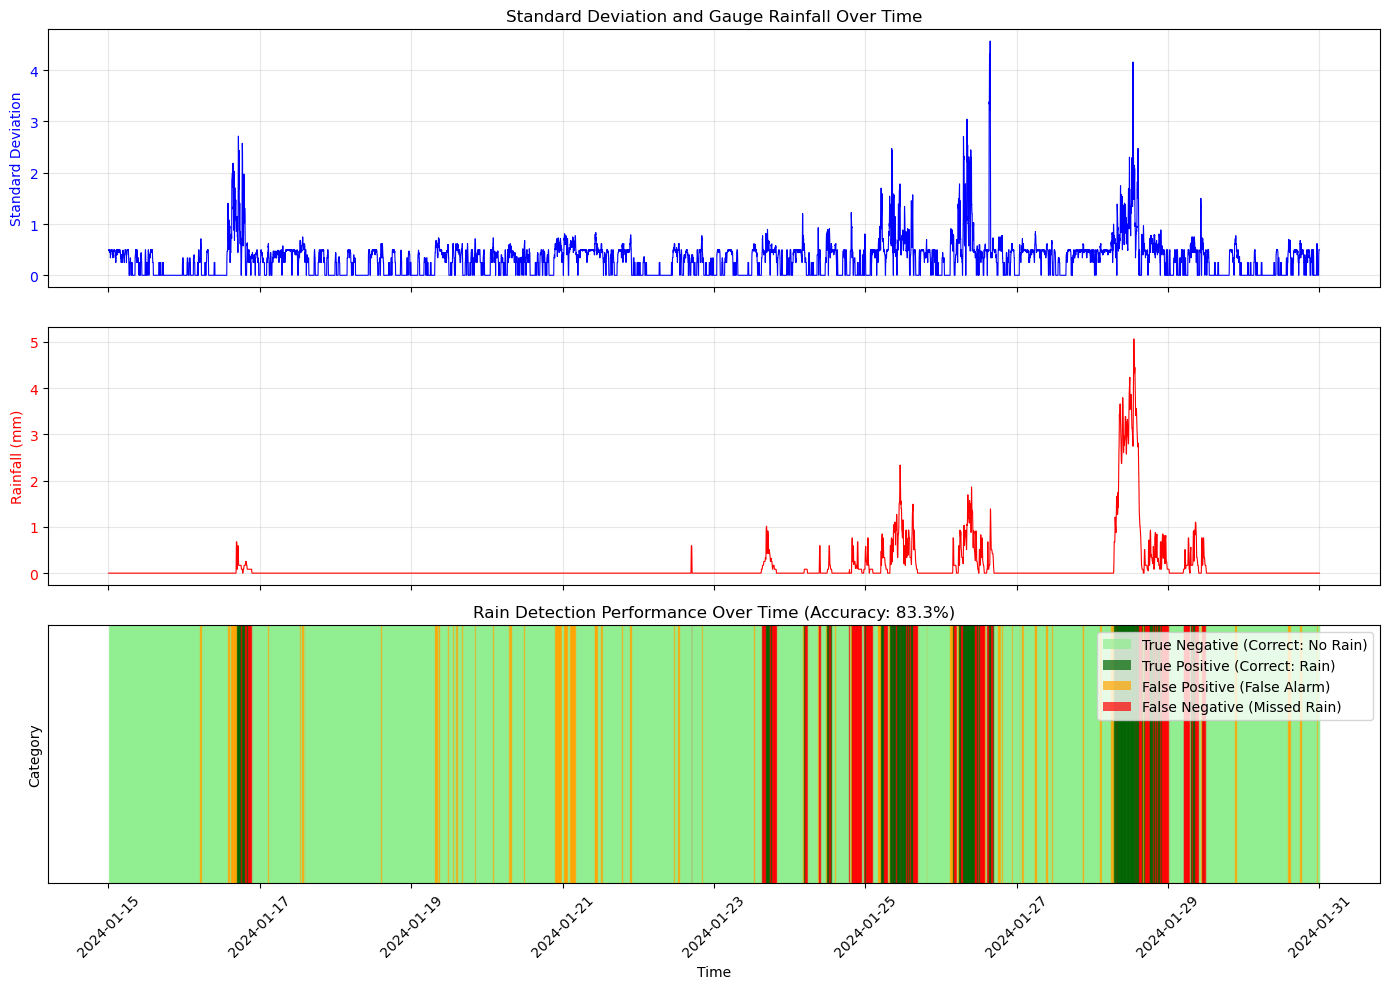

{'accuracy': 0.8333333333333334,
 'positive_acc': 0.47692307692307695,
 'negative_acc': 0.9059561128526645,
 'categories': array([0, 0, 0, ..., 0, 0, 0], shape=(1536,)),
 'time_array': array(['2024-01-15T00:10:00', '2024-01-15T00:25:00',
        '2024-01-15T00:40:00', ..., '2024-01-30T23:25:00',
        '2024-01-30T23:40:00', '2024-01-30T23:55:00'],
       shape=(1536,), dtype='datetime64[s]'),
 'true_positives': 124,
 'true_negatives': 1156,
 'false_positives': 120,
 'false_negatives': 136}

In [43]:
rain_detection(link_set.get_link(2), 0.55, 15, True, False)

### Detection for every high-frequency sublink
### std threshold = 0.55

link frequency: 68.04


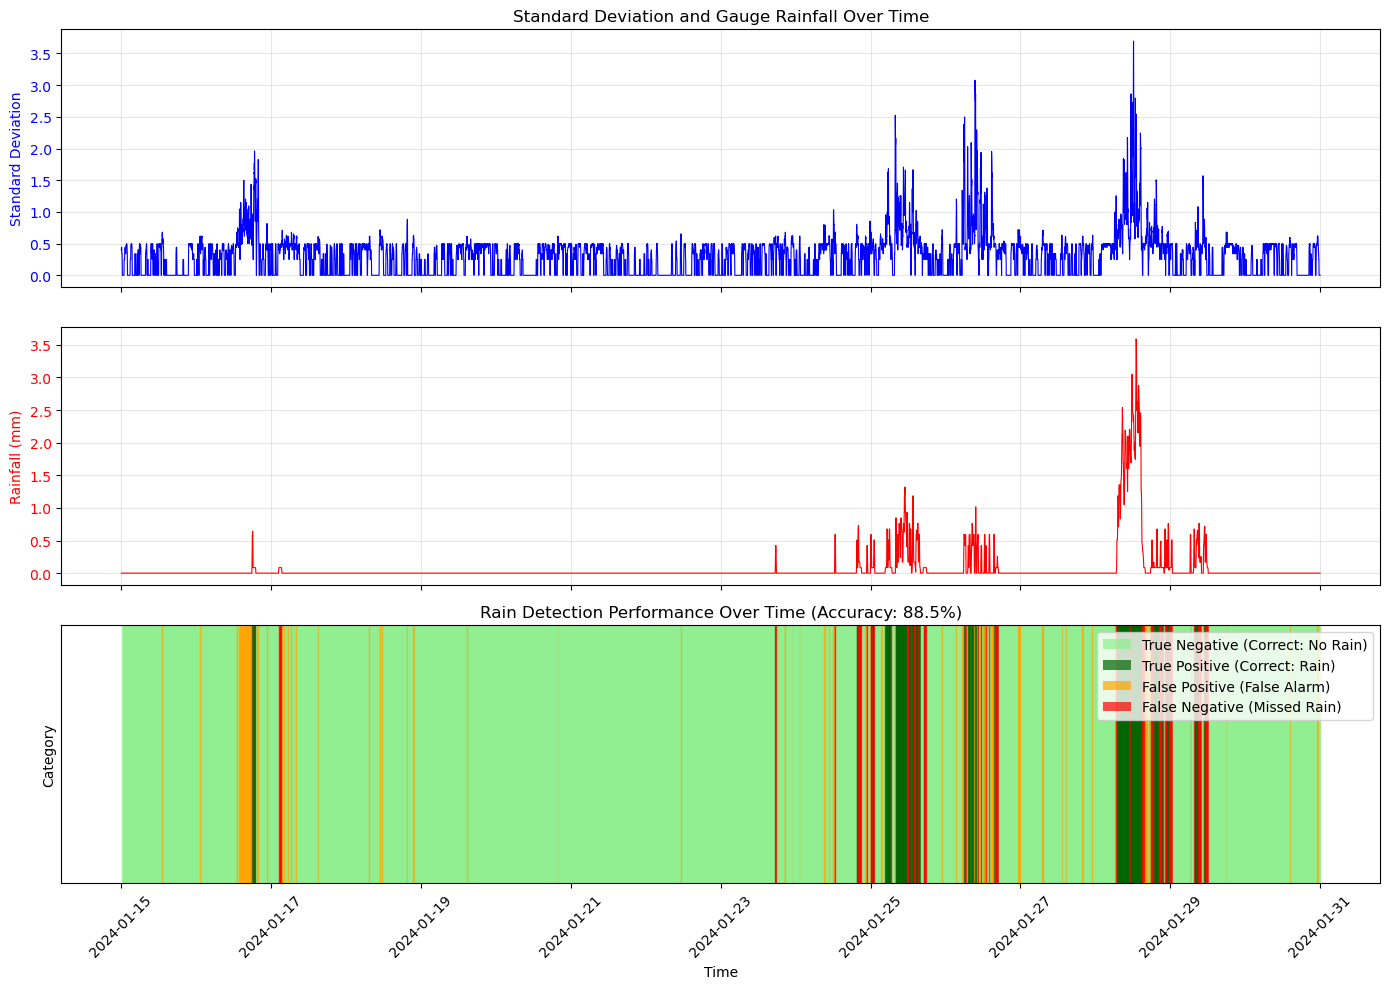

link frequency: 68.04


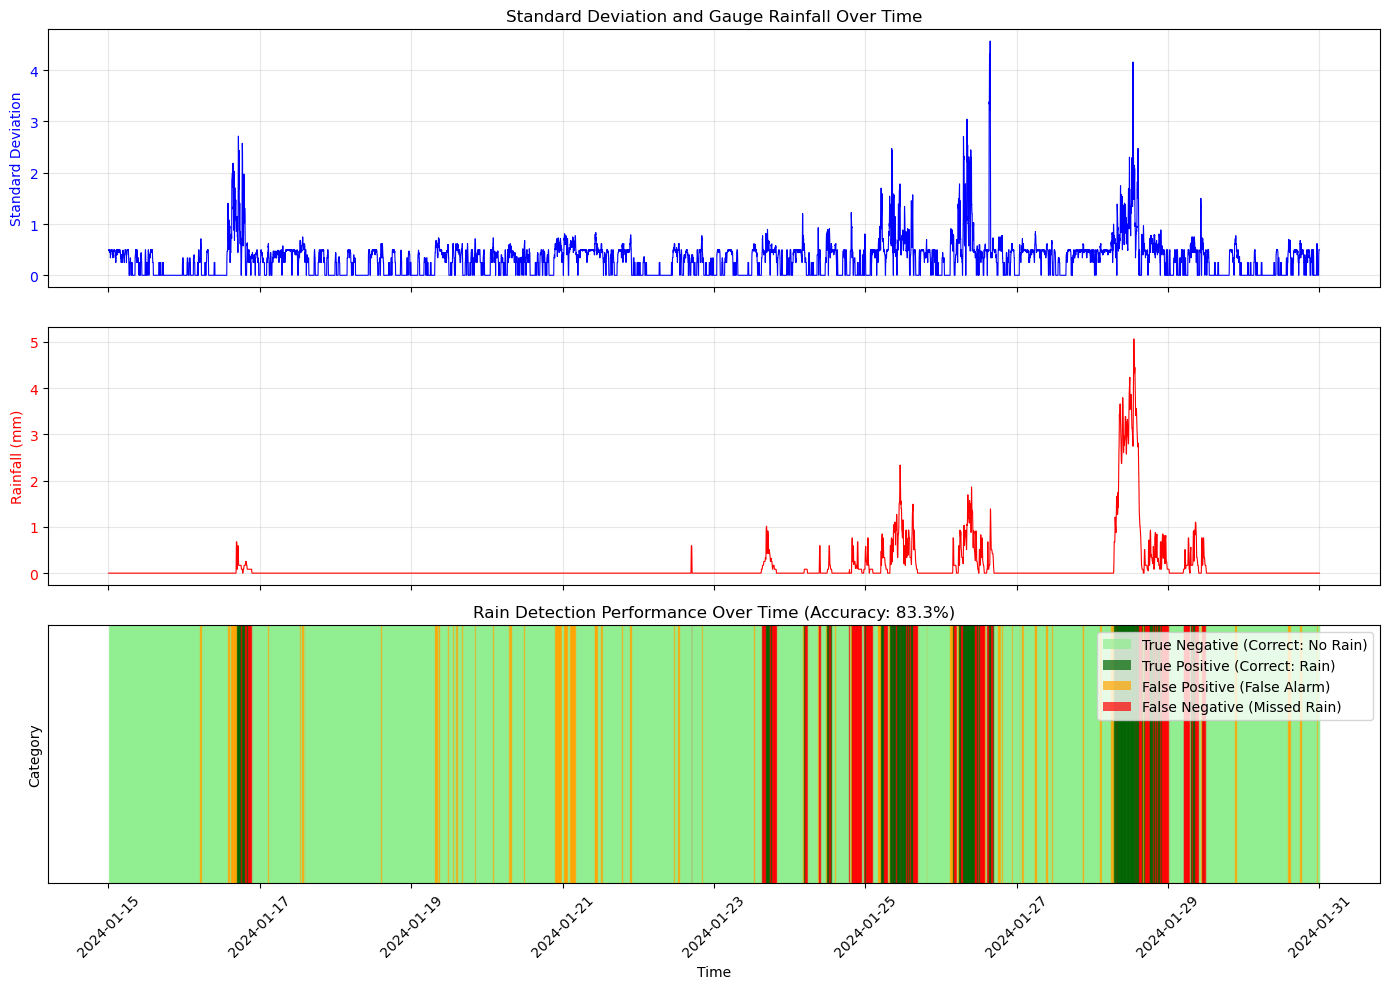

link frequency: 68.04


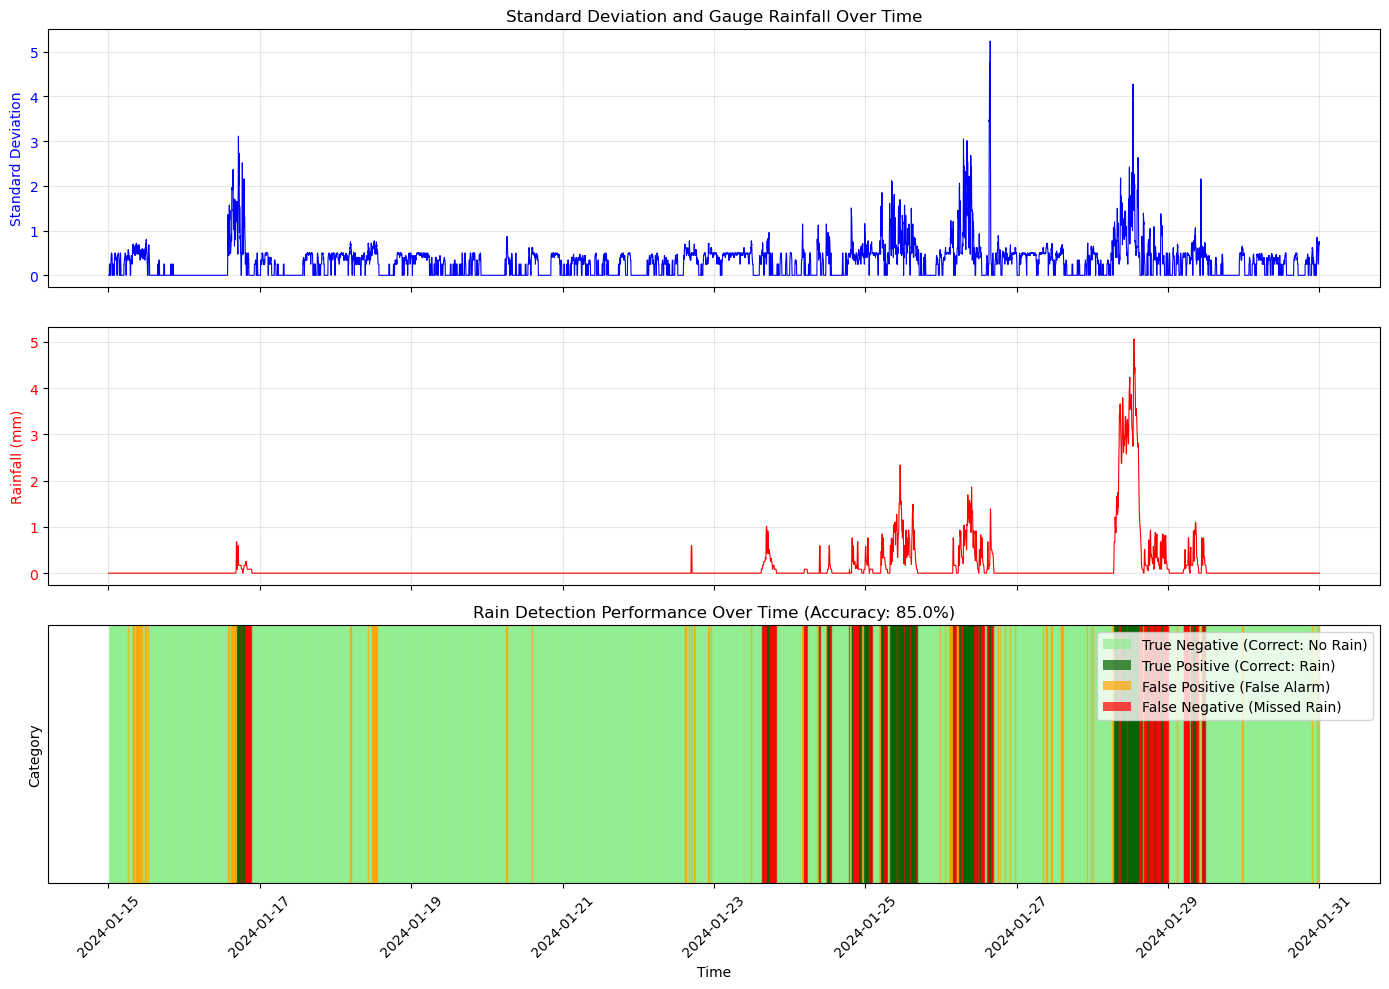

link frequency: 68.04


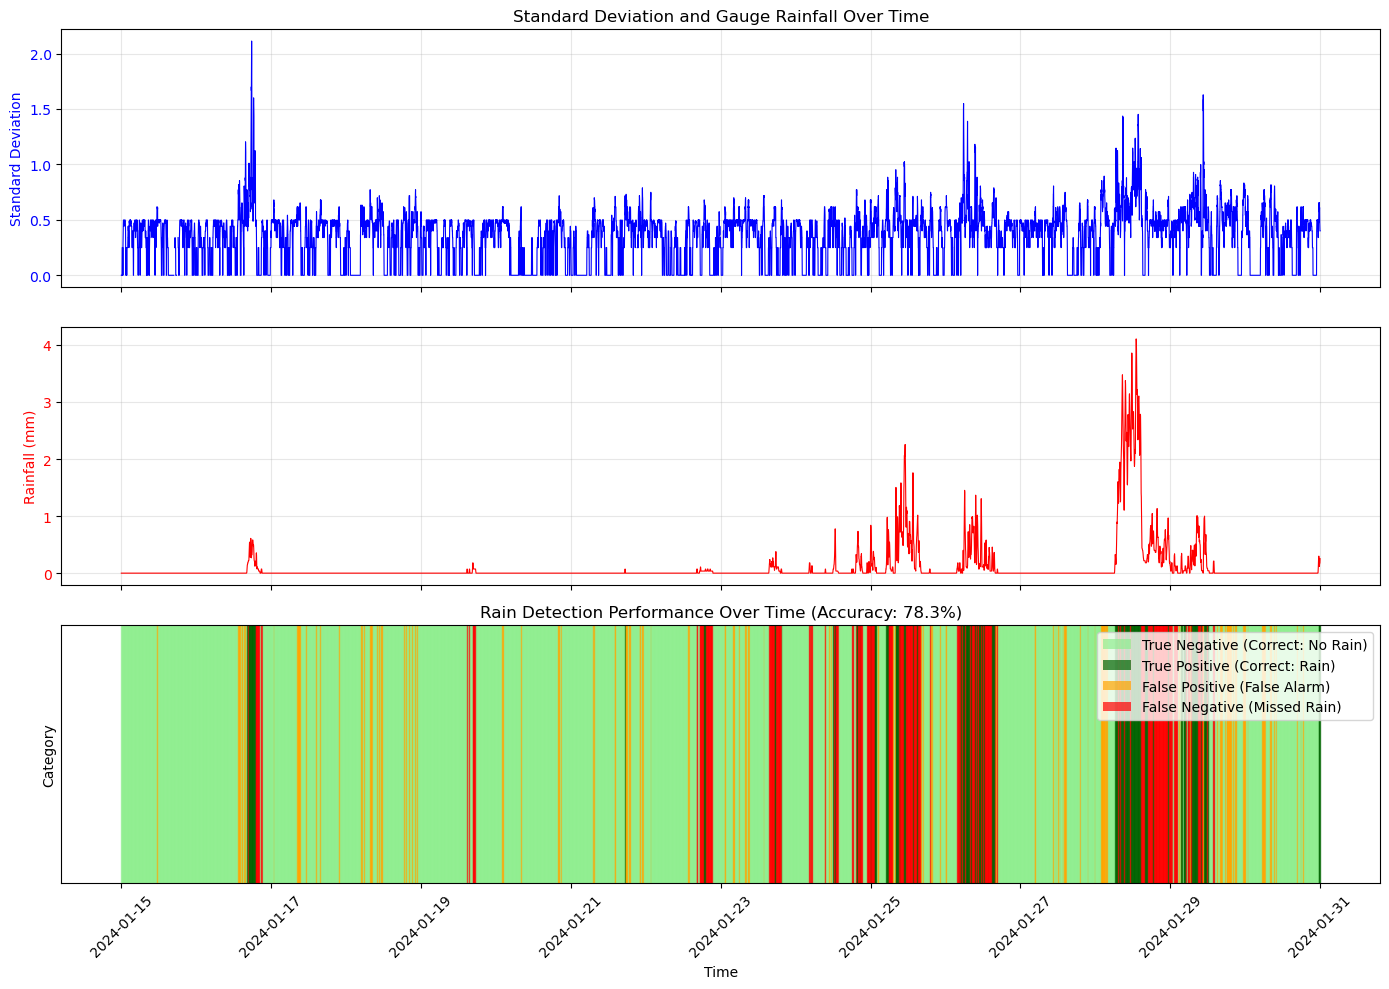

link frequency: 69.12


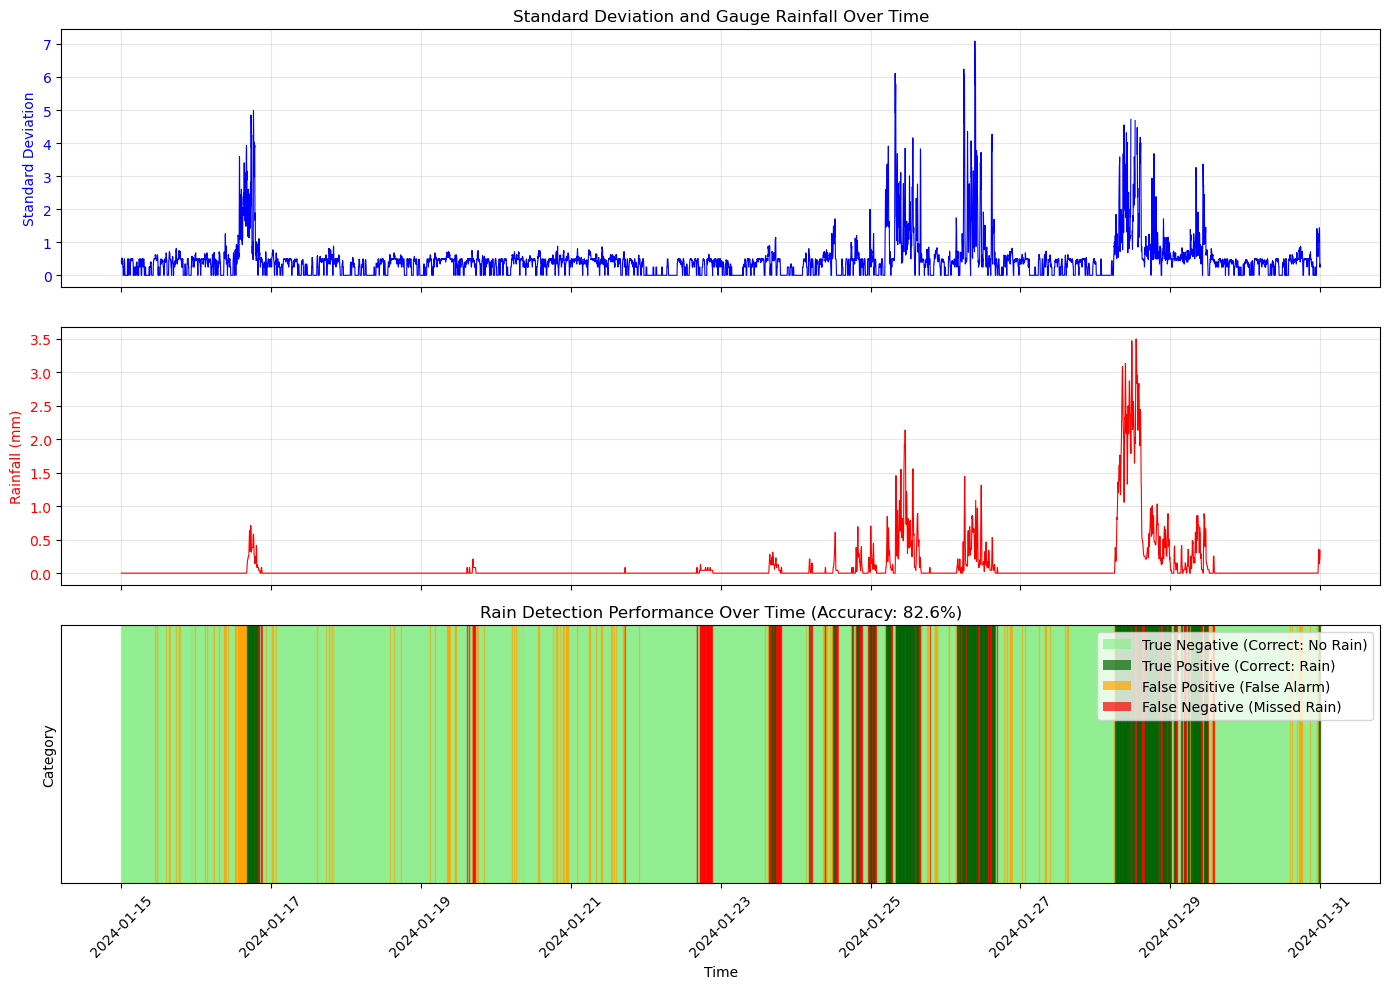

link frequency: 69.12


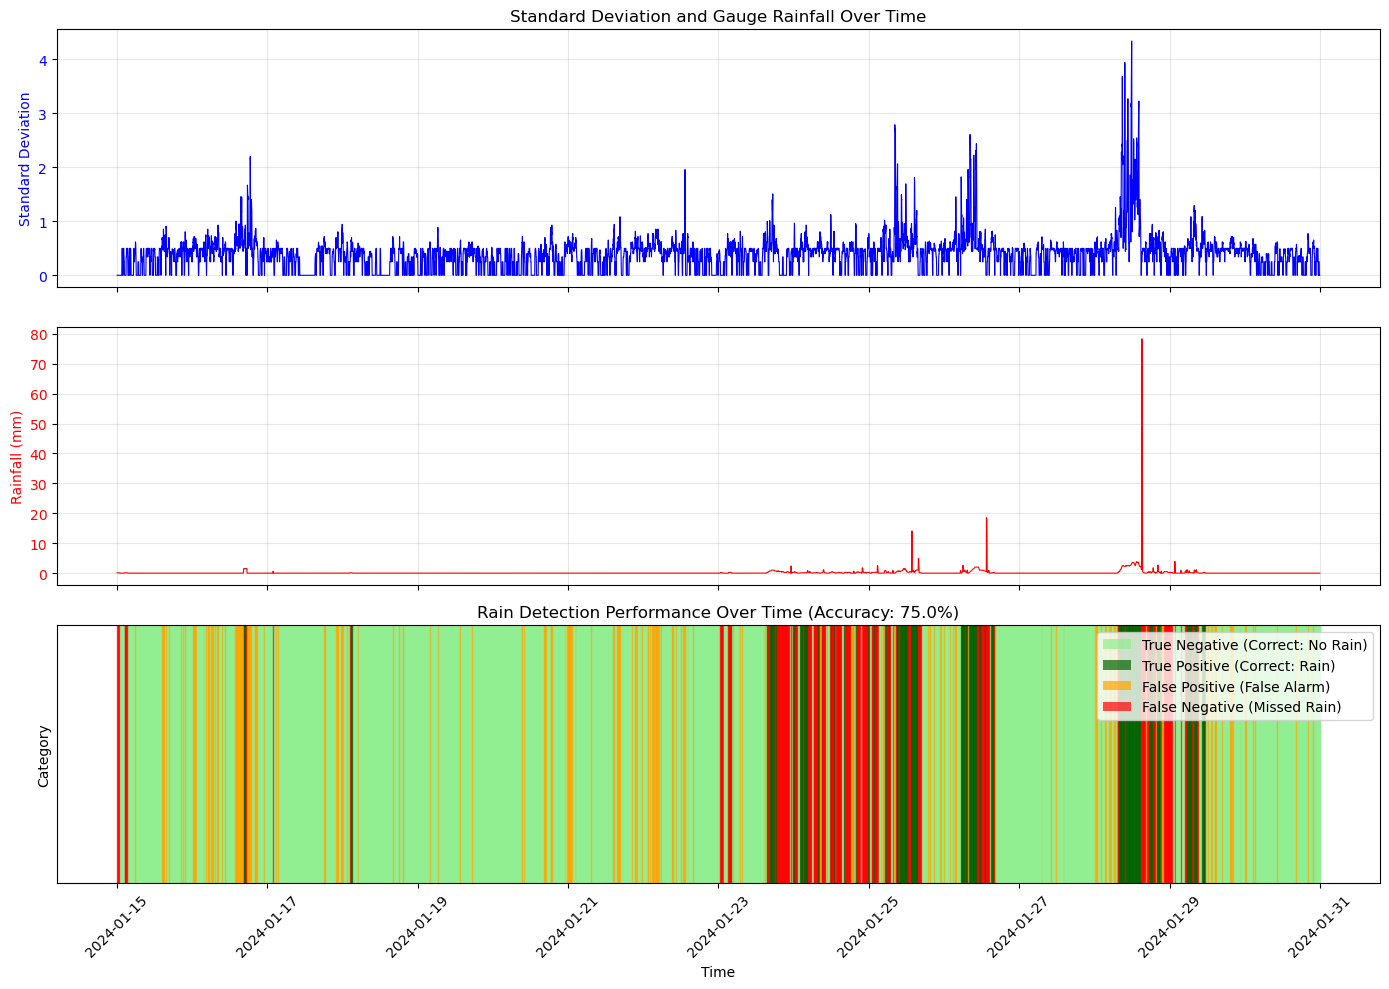

link frequency: 68.04


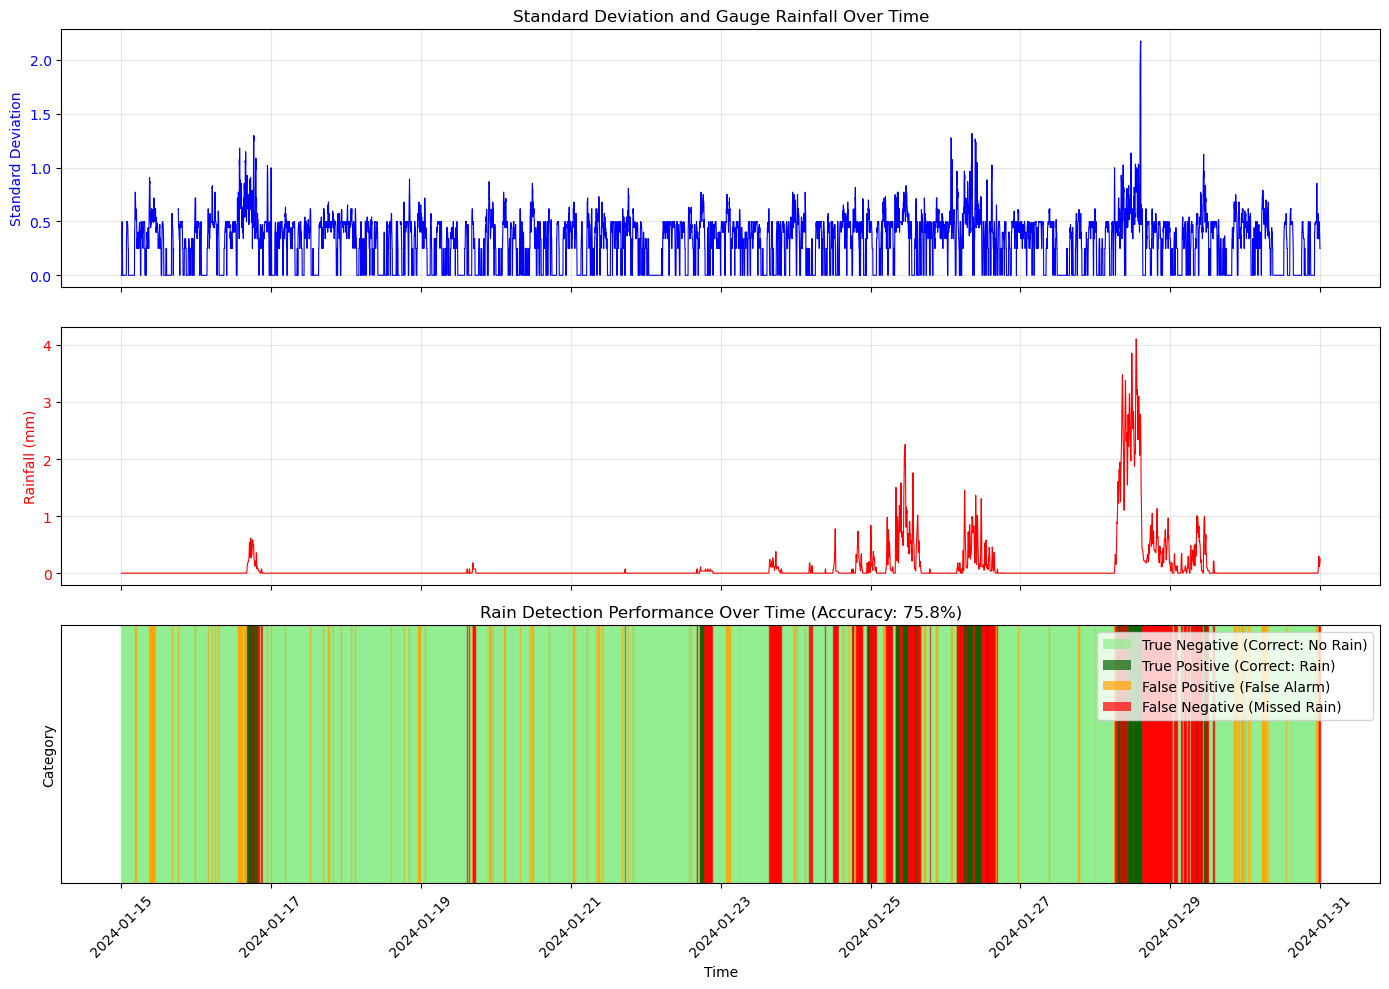

link frequency: 68.04


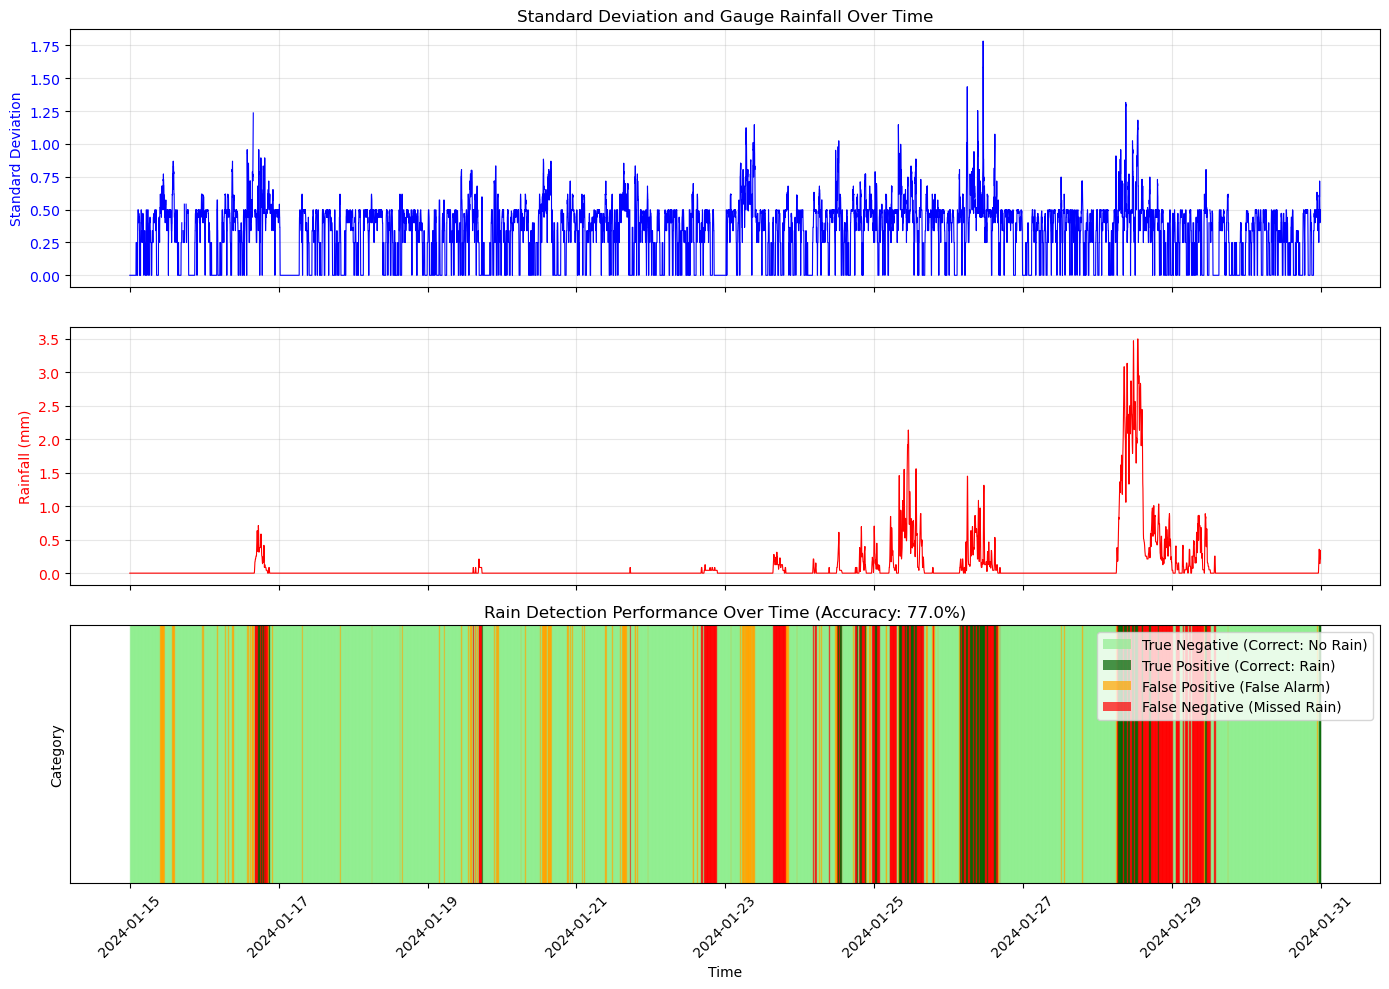

link frequency: 68.04


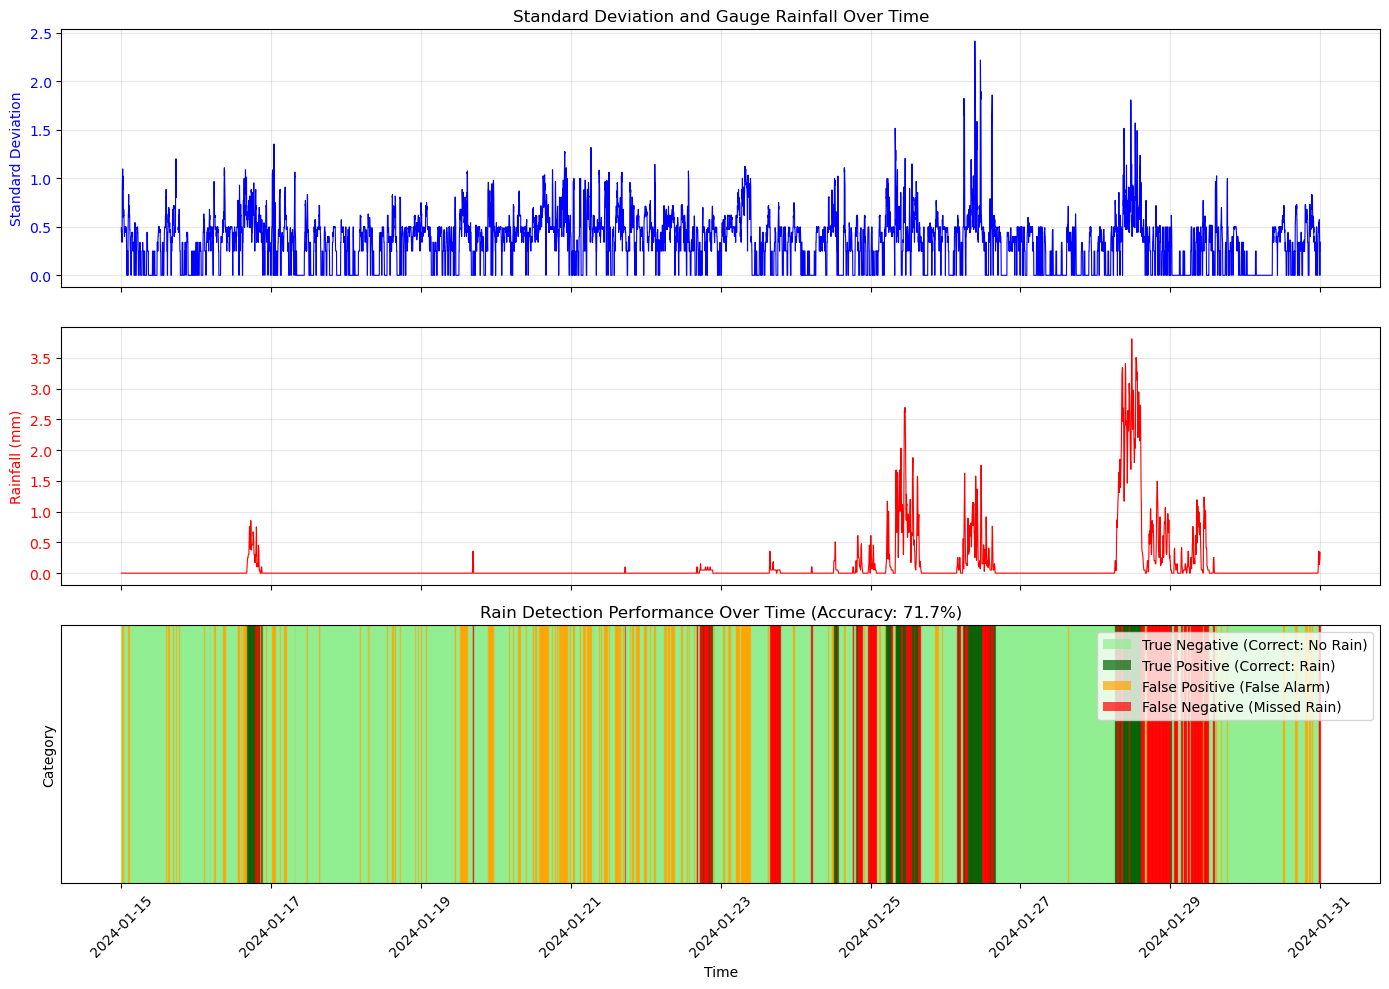

link frequency: 68.04


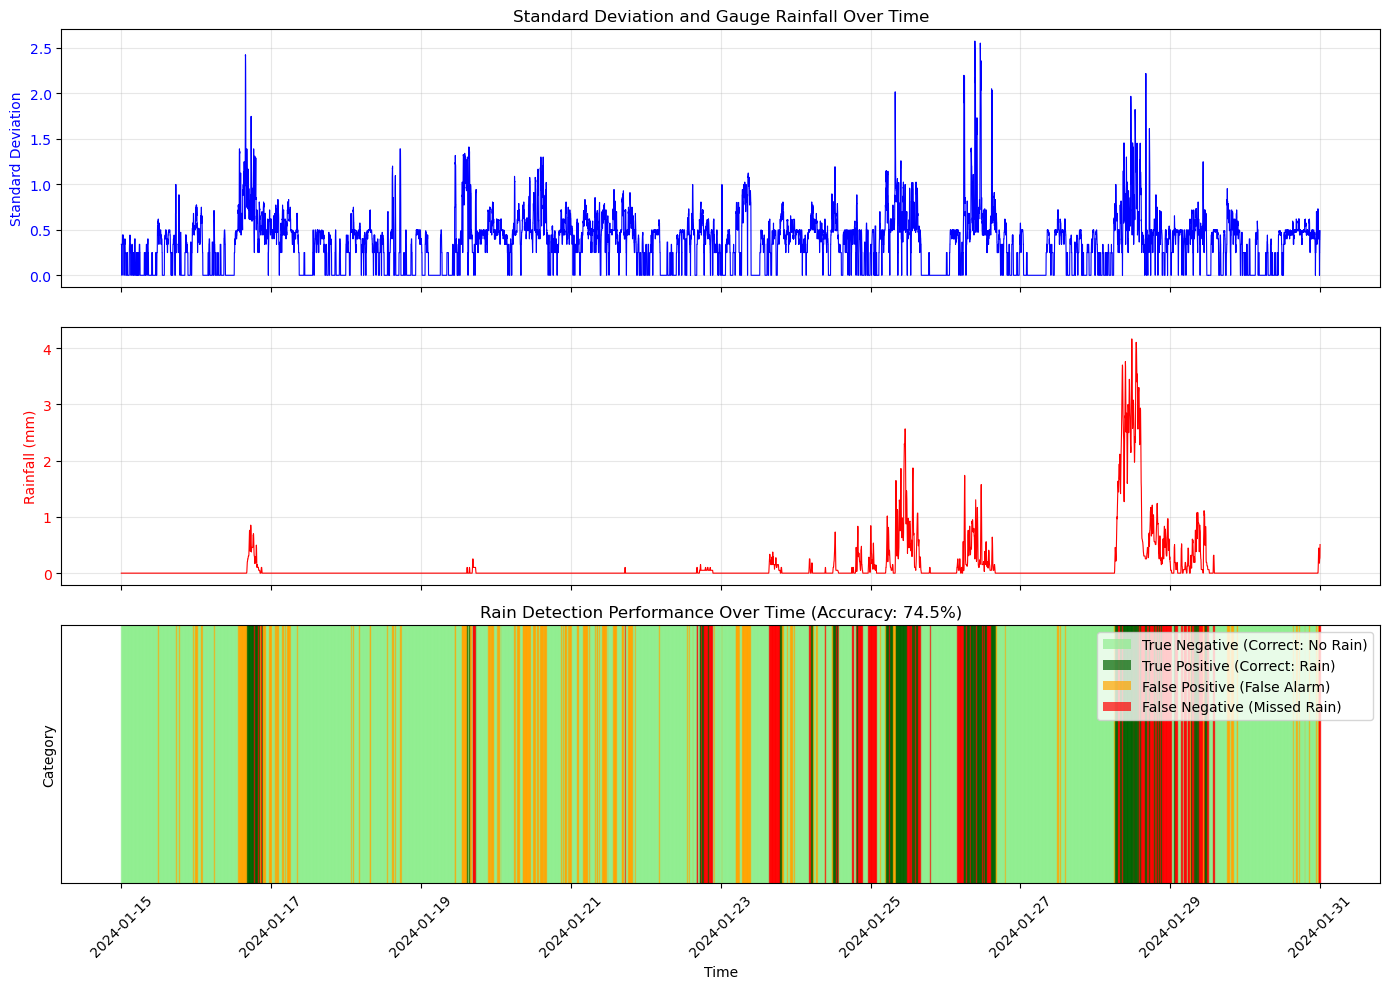

link frequency: 68.04


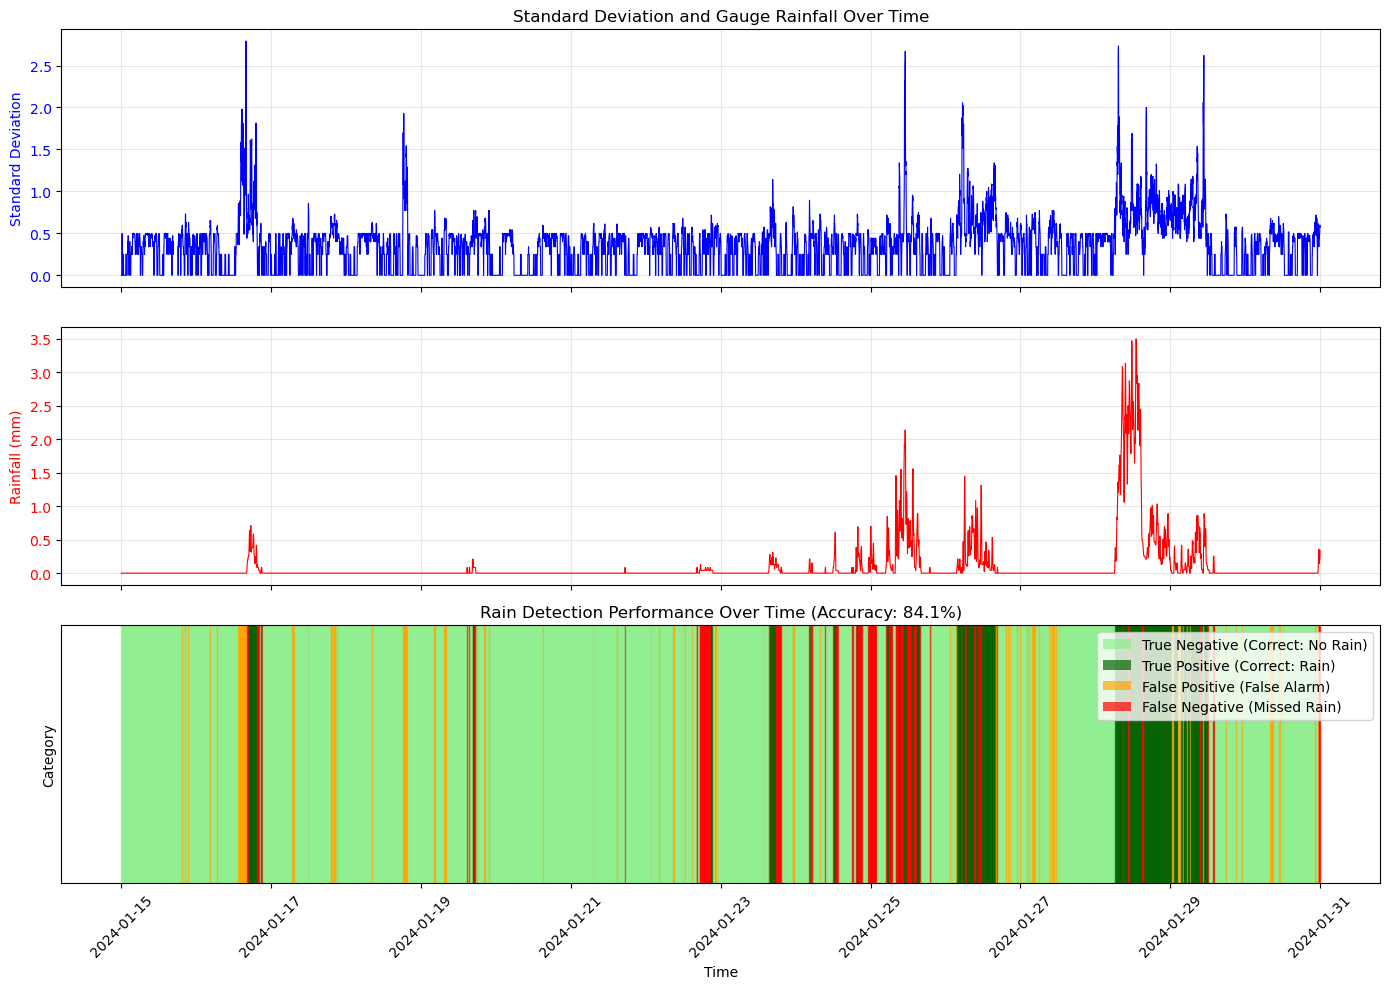

link frequency: 68.04


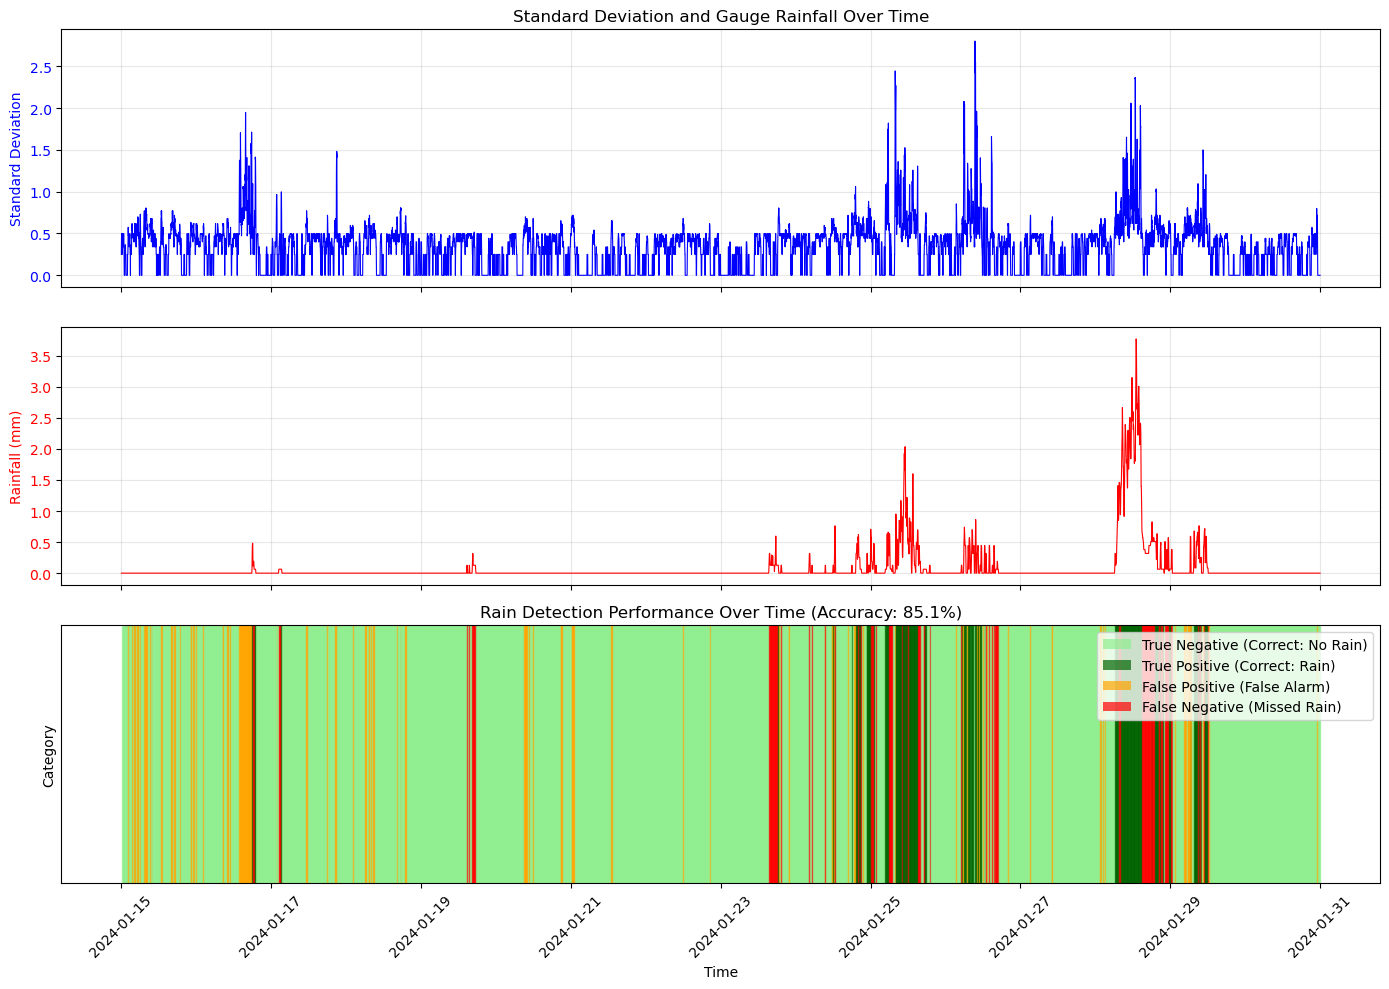

link frequency: 68.04


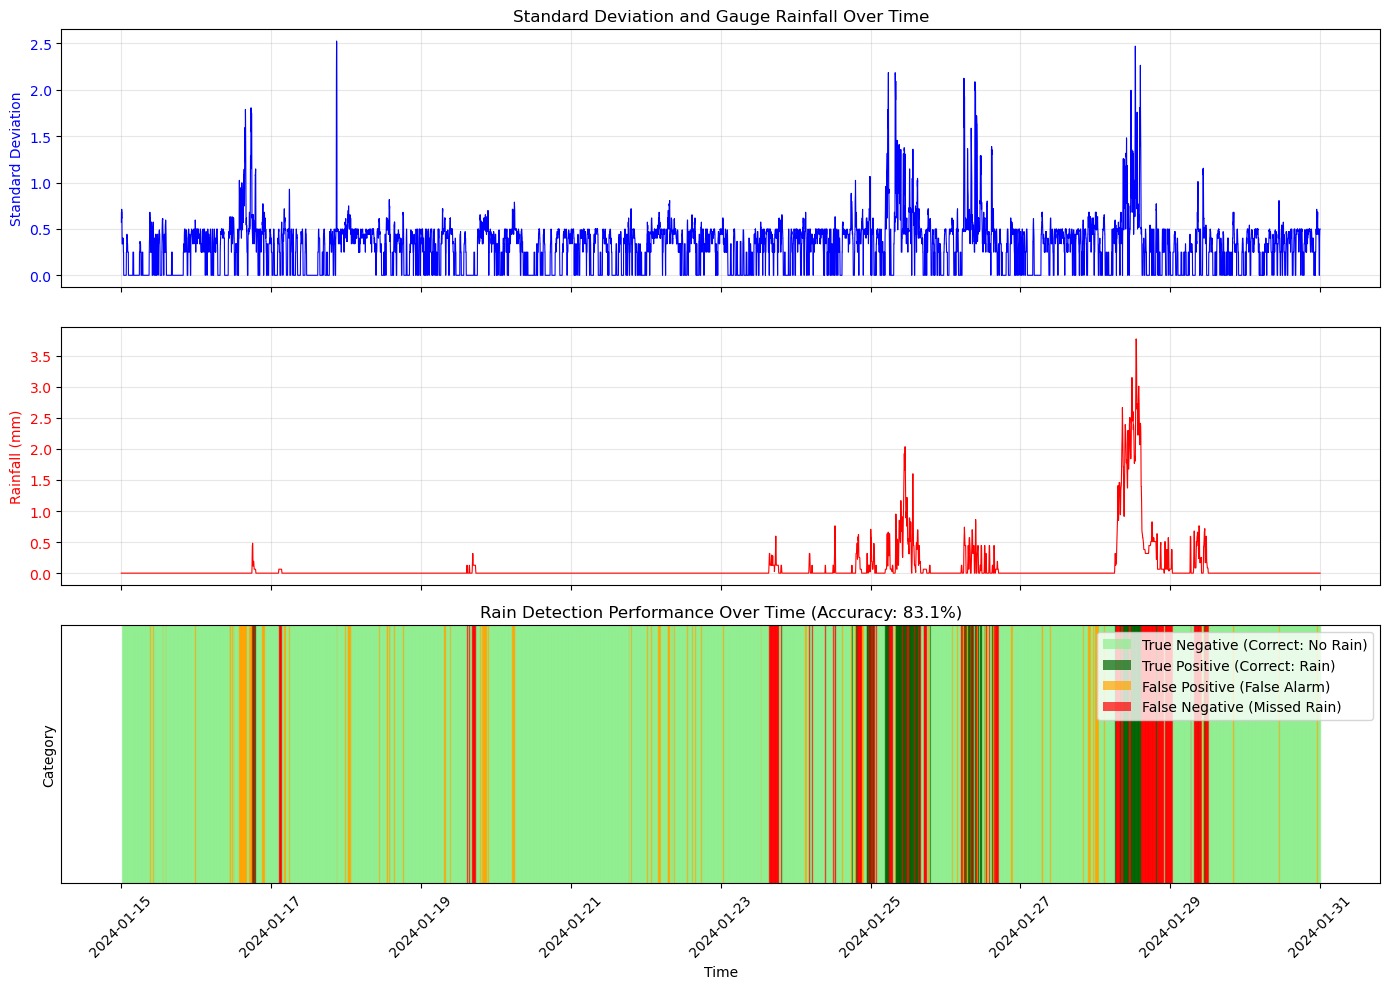

link frequency: 68.04


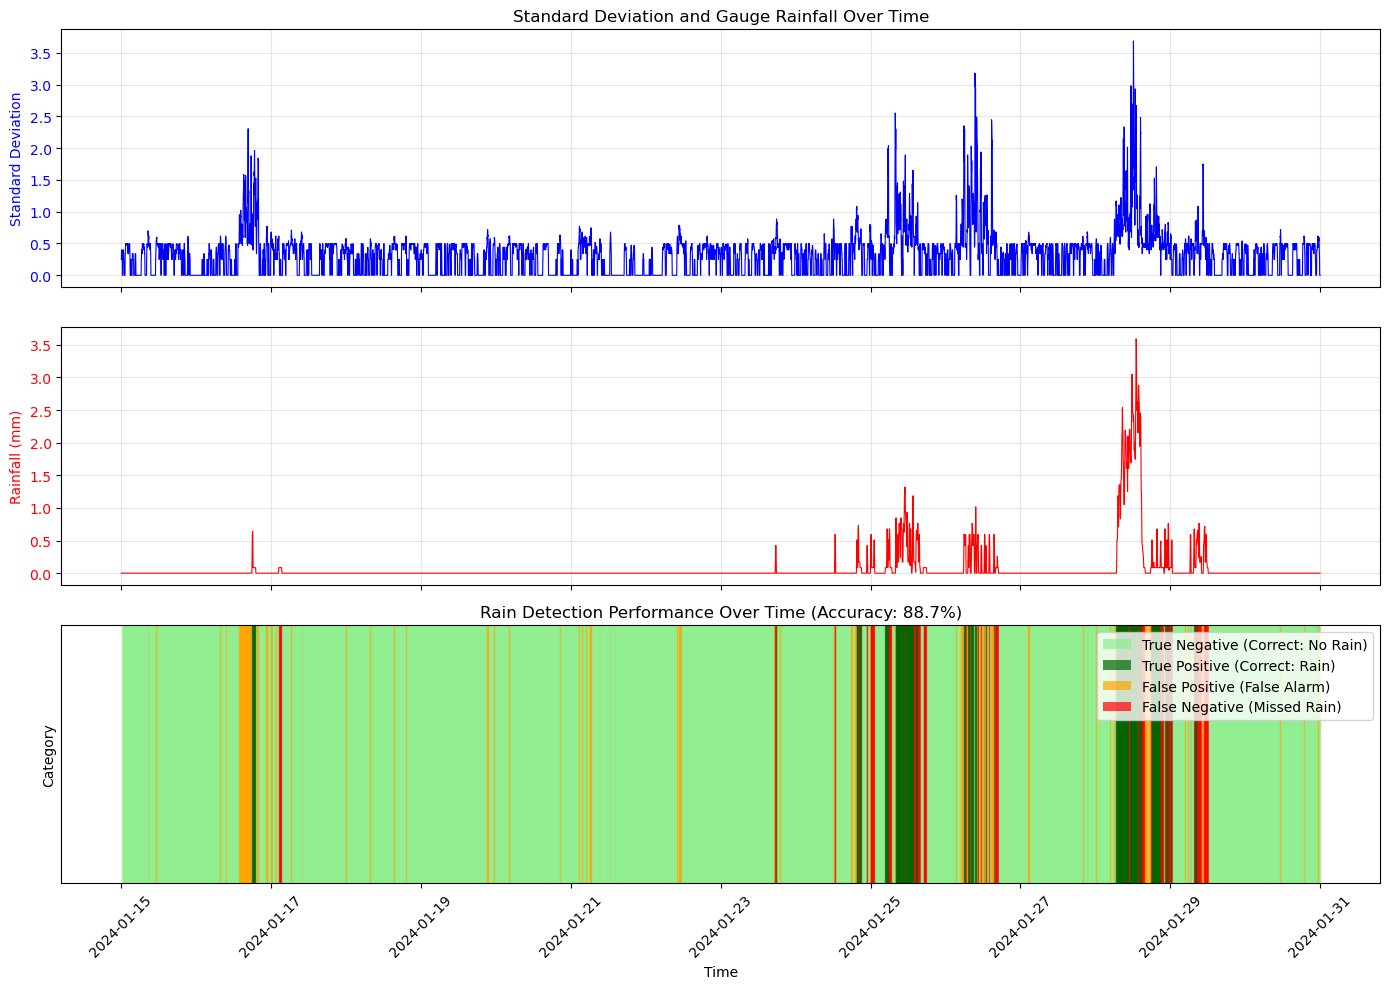

link frequency: 68.04


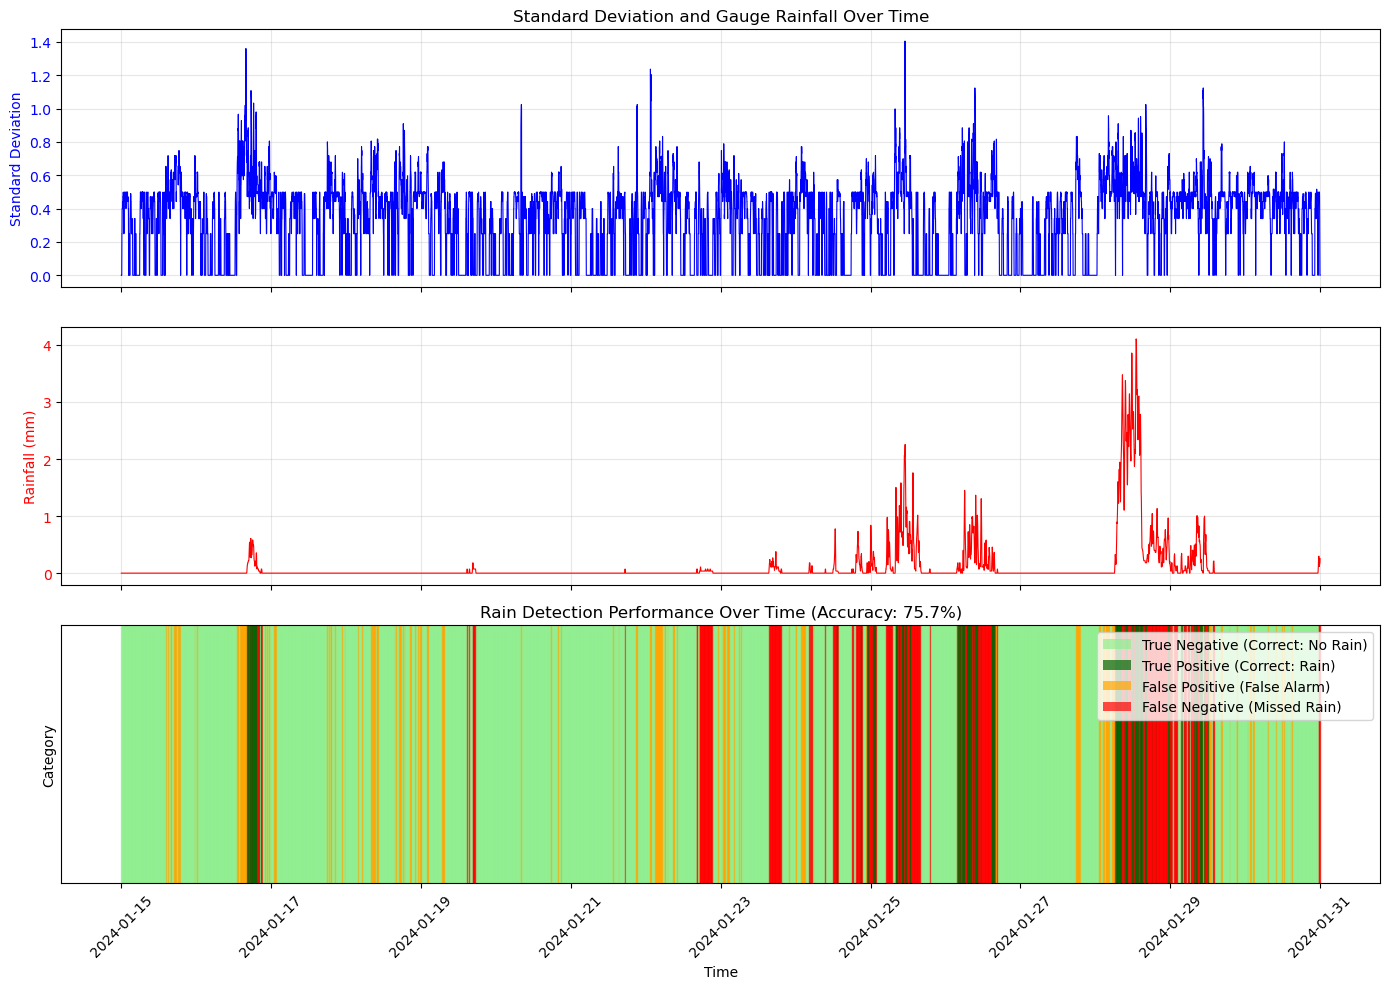

link frequency: 68.04


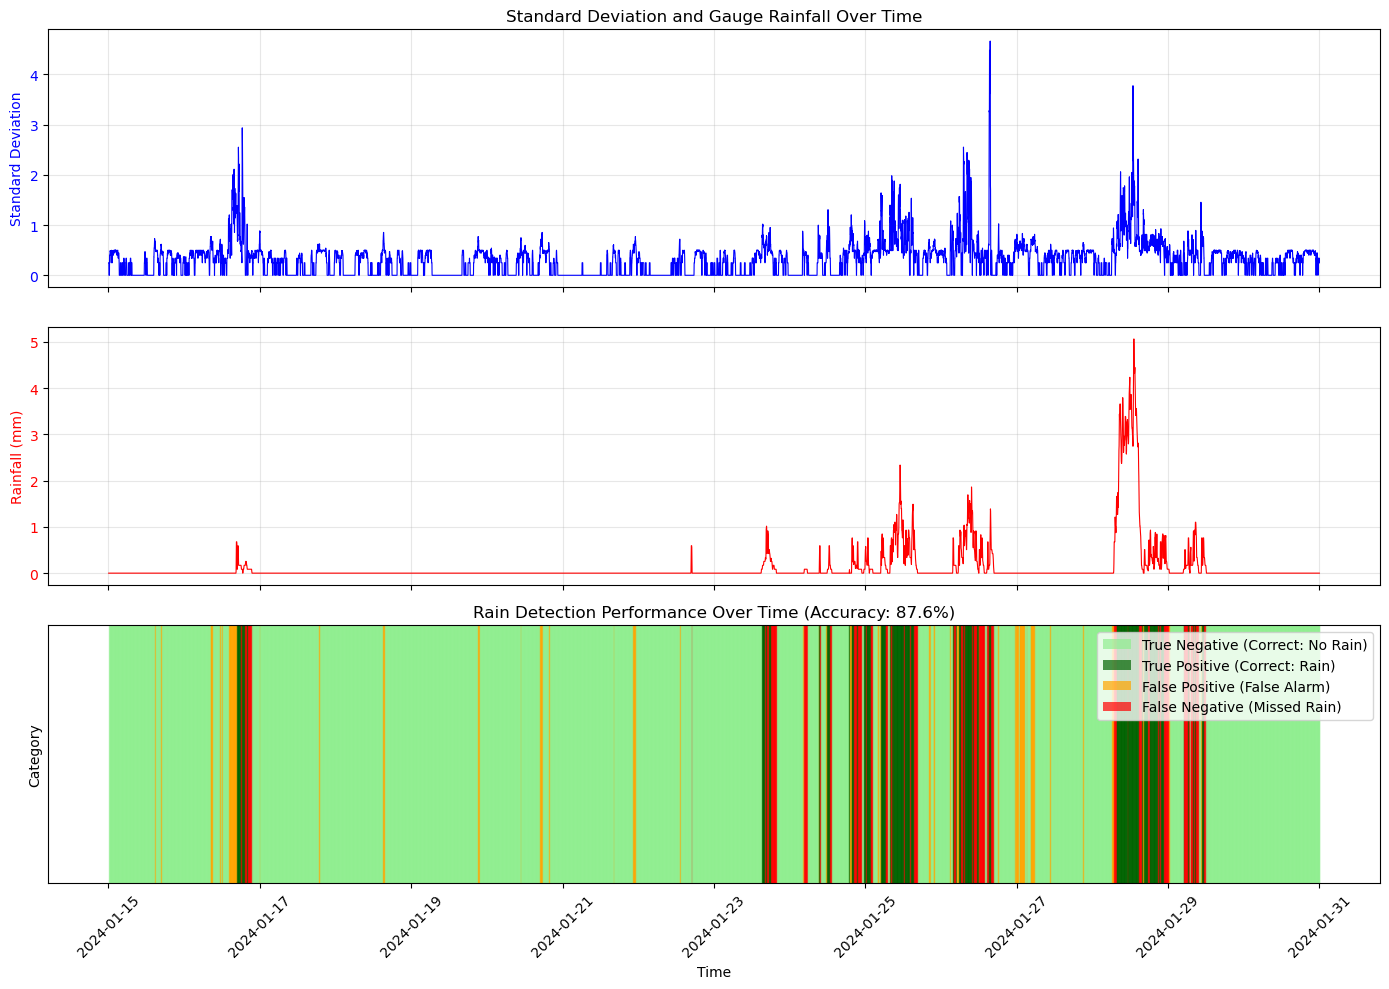

In [44]:
for i in highfreqID:
    print(f'link frequency: {link_set.get_link(i).meta_data.frequency}')
    rain_detection(link_set.get_link(i), 0.55, 15, True, False)